In [19]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [23]:
df.shape

(438, 36)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438 entries, 0 to 437
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Synthesizable               438 non-null    bool   
 1   Material ID                 438 non-null    object 
 2   Formula                     438 non-null    object 
 3   Crystal System              438 non-null    object 
 4   Space Group Symbol          438 non-null    object 
 5   Space Group Number          438 non-null    int64  
 6   Sites                       438 non-null    int64  
 7   Energy Above Hull           438 non-null    float64
 8   Formation Energy            438 non-null    float64
 9   Predicted Stable            438 non-null    bool   
 10  Volume                      438 non-null    float64
 11  Density                     438 non-null    float64
 12  Band Gap                    438 non-null    float64
 13  Is Gap Direct               438 non

In [20]:
df = pd.read_csv("../data/processed/Si_ML_ready.csv")
df.head()

,Unnamed: 0,Synthesizable,Material ID,Formula,Crystal System,Space Group Symbol,Space Group Number,Sites,Energy Above Hull,Formation Energy,...,Shape Factor,Work Function,Piezoelectric Modulus,Total Dielectric Constant,Ionic Dielectric Constant,Static Dielectric Constant,Si_frac,O_frac,C_frac,N_frac
0,0,True,mp-1244933,Si,Triclinic,P1,1,100,0.349291,0.349291,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0
1,1,True,mp-1120447,Si,Triclinic,P1,1,8,0.372510,0.372510,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0
2,2,True,mp-1244971,Si,Triclinic,P1,1,100,0.316752,0.316752,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0
3,3,True,mp-1244990,Si,Triclinic,P1,1,100,0.366274,0.366274,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0
4,4,True,mp-1245242,Si,Triclinic,P1,1,100,0.316910,0.316910,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0


In [21]:
df = df.drop(columns=["Unnamed: 0"])

In [24]:
df.to_csv("../data/processed/Si_ML_ready_clean.csv", index=False)

In [10]:
df["Band Gap"].describe()

count    438.000000
mean       3.919211
std        2.272792
min        0.000000
25%        1.706200
50%        5.450500
75%        5.665925
max        6.310200
Name: Band Gap, dtype: float64

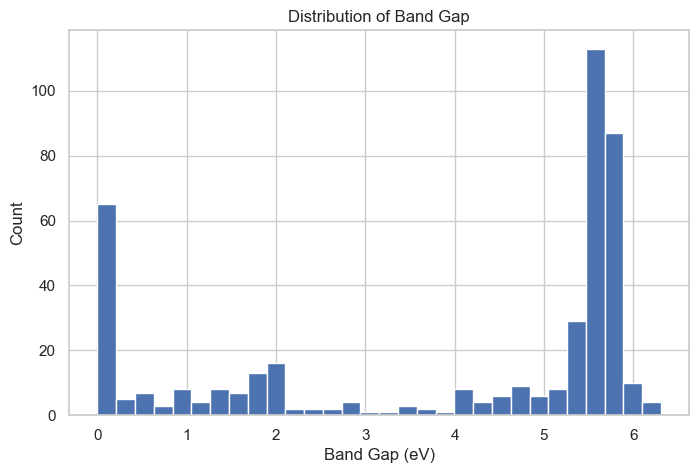

In [11]:
import matplotlib.pyplot as plt

plt.hist(df["Band Gap"], bins=30)
plt.xlabel("Band Gap (eV)")
plt.ylabel("Count")
plt.title("Distribution of Band Gap")
plt.show()

COMPOSITION INFLUENCE

Band Gap vs Si_frac

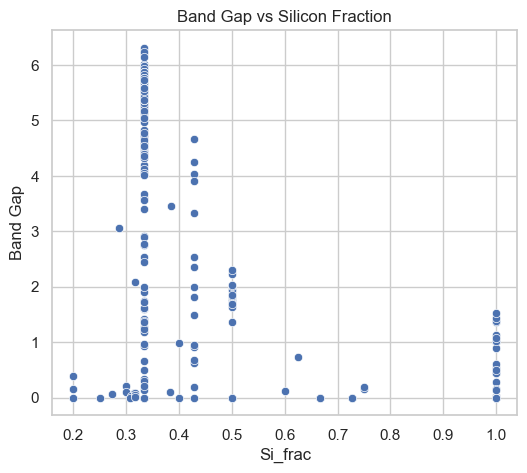

In [15]:
plt.figure(figsize=(6,5))
sns.scatterplot(x="Si_frac", y="Band Gap", data=df)
plt.title("Band Gap vs Silicon Fraction")
plt.show()

Band Gap vs O_frac

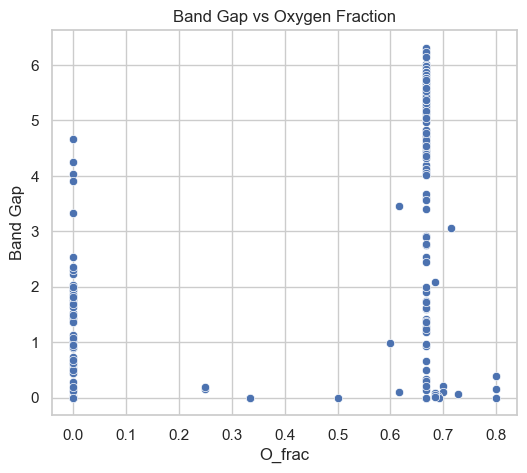

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.scatterplot(x="O_frac", y="Band Gap", data=df)
plt.title("Band Gap vs Oxygen Fraction")
plt.show()

Number of Si–O samples: 343
     O_frac     mean       std  count
0  0.250000  0.17385  0.020718      2
1  0.333333  0.00000  0.000000      2
2  0.500000  0.00000       NaN      1
3  0.600000  0.98890       NaN      1
4  0.615385  3.45280       NaN      1


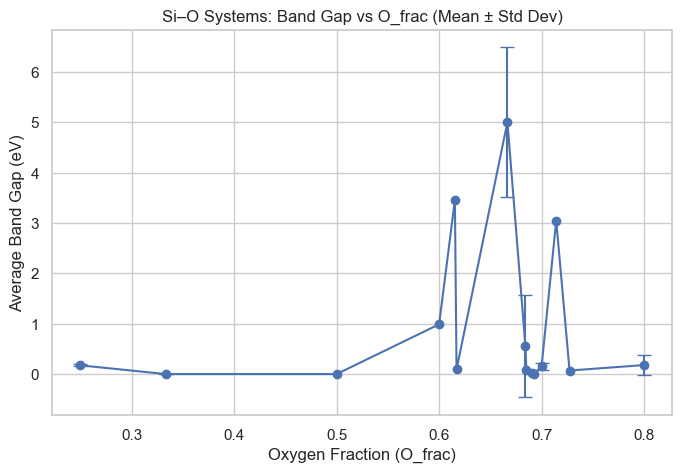

In [34]:
df_sio = df[
    (df["Si_frac"] > 0) &
    (df["O_frac"] > 0) &
    (df["C_frac"] == 0) &
    (df["N_frac"] == 0)
].copy()

print("Number of Si–O samples:", len(df_sio))

grouped_sio = (
    df_sio
    .groupby("O_frac")["Band Gap"]
    .agg(["mean", "std", "count"])
    .reset_index()
)

print(grouped_sio.head())

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.errorbar(
    grouped_sio["O_frac"],
    grouped_sio["mean"],
    yerr=grouped_sio["std"],
    fmt="o-",
    capsize=5
)

plt.xlabel("Oxygen Fraction (O_frac)")
plt.ylabel("Average Band Gap (eV)")
plt.title("Si–O Systems: Band Gap vs O_frac (Mean ± Std Dev)")
plt.grid(True)

plt.show()

STRUCTURAL INFLUENCE

Band Gap vs Crystal System

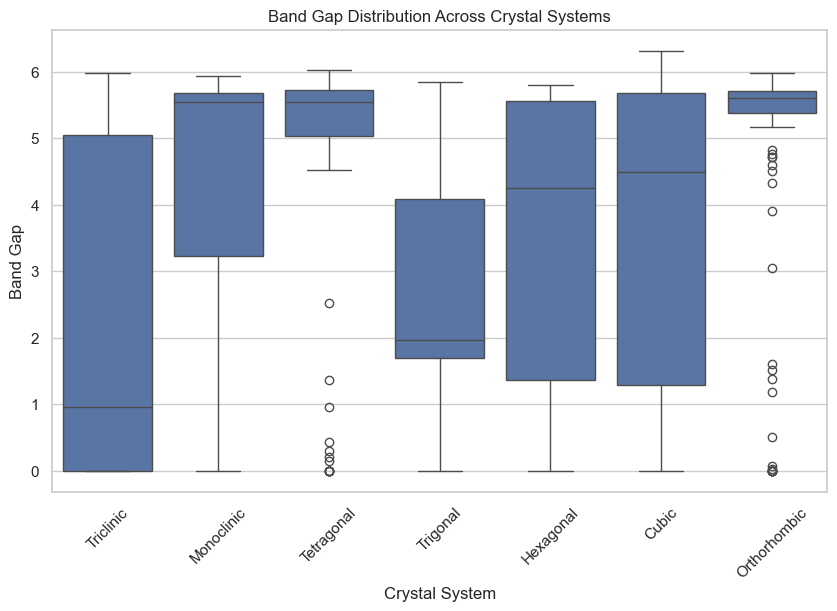

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(x="Crystal System", y="Band Gap", data=df)
plt.xticks(rotation=45)
plt.title("Band Gap Distribution Across Crystal Systems")
plt.show()

In [18]:
df_si = df[(df["O_frac"] == 0) & 
           (df["C_frac"] == 0) & 
           (df["N_frac"] == 0)]

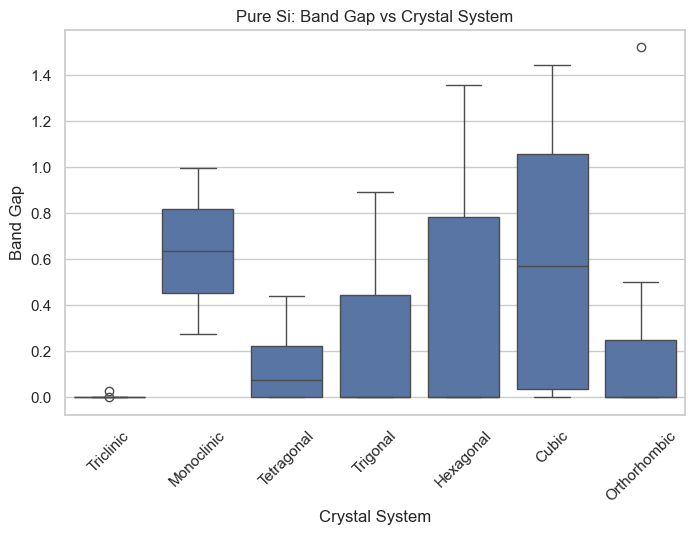

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="Crystal System", y="Band Gap", data=df_si)
plt.title("Pure Si: Band Gap vs Crystal System")
plt.xticks(rotation=45)
plt.show()

In [27]:
df_sio = df[
    (df["O_frac"] > 0) &
    (df["C_frac"] == 0) &
    (df["N_frac"] == 0)
]

In [28]:
df_sio.shape

(343, 36)

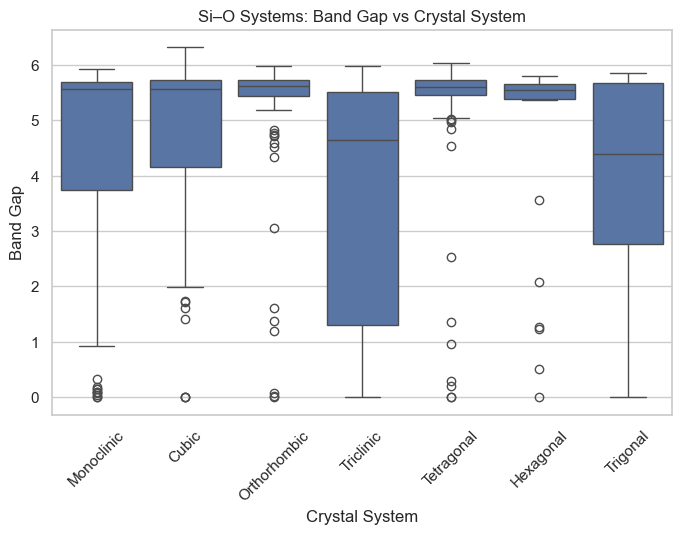

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="Crystal System", y="Band Gap", data=df_sio)

plt.xticks(rotation=45)
plt.title("Si–O Systems: Band Gap vs Crystal System")
plt.show()

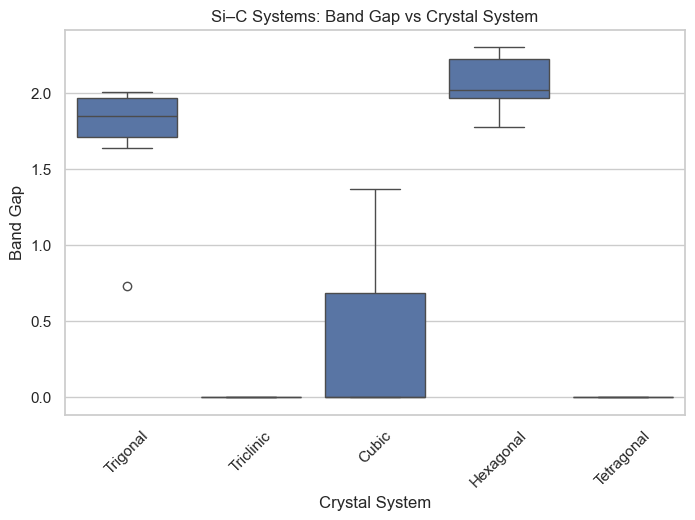

In [30]:
df_sic = df[
    (df["C_frac"] > 0) &
    (df["O_frac"] == 0) &
    (df["N_frac"] == 0)
]

plt.figure(figsize=(8,5))
sns.boxplot(x="Crystal System", y="Band Gap", data=df_sic)
plt.xticks(rotation=45)
plt.title("Si–C Systems: Band Gap vs Crystal System")
plt.show()

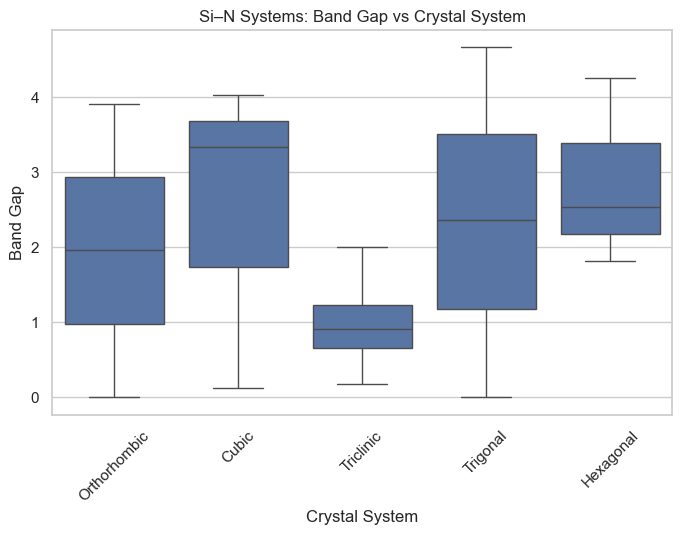

In [31]:
df_sin = df[
    (df["N_frac"] > 0) &
    (df["O_frac"] == 0) &
    (df["C_frac"] == 0)
]

plt.figure(figsize=(8,5))
sns.boxplot(x="Crystal System", y="Band Gap", data=df_sin)
plt.xticks(rotation=45)
plt.title("Si–N Systems: Band Gap vs Crystal System")
plt.show()

PHYSICAL INFLUENCE

Band Gap vs Density

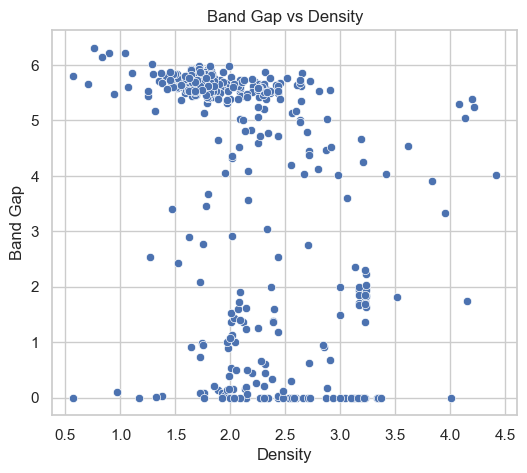

In [19]:
plt.figure(figsize=(6,5))
sns.scatterplot(x="Density", y="Band Gap", data=df)
plt.title("Band Gap vs Density")
plt.show()

Band Gap vs Volume

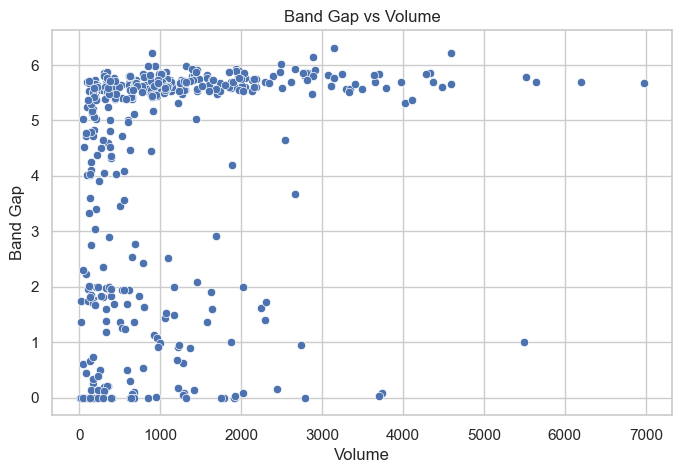

In [20]:
sns.scatterplot(x="Volume", y="Band Gap", data=df)
plt.title("Band Gap vs Volume")
plt.show()

In [ ]:
STABILITY INFLUENCE

In [16]:
corr = df["Band Gap"].corr(df["Energy Above Hull"])
print("Correlation between Band Gap and Energy Above Hull:", corr)

Correlation between Band Gap and Energy Above Hull: -0.5567158148338541


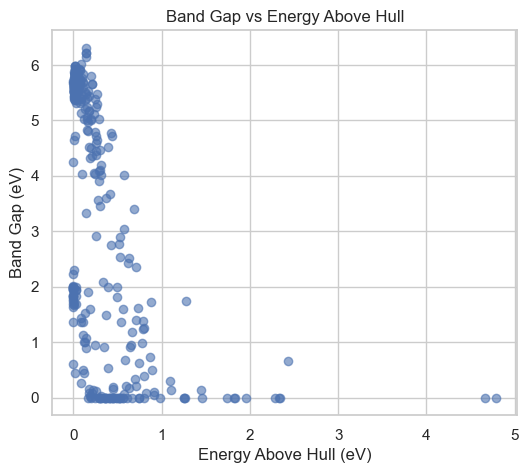

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(df["Energy Above Hull"], df["Band Gap"], alpha=0.6)

plt.xlabel("Energy Above Hull (eV)")
plt.ylabel("Band Gap (eV)")
plt.title("Band Gap vs Energy Above Hull")
plt.grid(True)

plt.show()

In [36]:
correlation_fe = df["Band Gap"].corr(df["Formation Energy"])
print("Correlation between Band Gap and Formation Energy:", correlation_fe)

Correlation between Band Gap and Formation Energy: -0.8432025057406217


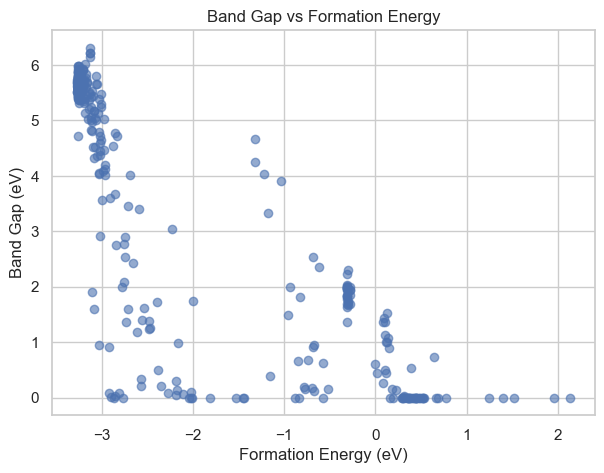

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(df["Formation Energy"], df["Band Gap"], alpha=0.6)

plt.xlabel("Formation Energy (eV)")
plt.ylabel("Band Gap (eV)")
plt.title("Band Gap vs Formation Energy")
plt.grid(True)

plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by exact O_frac values
grouped = df.groupby("O_frac")["Band Gap"].agg(["mean", "std", "count"]).reset_index()

print(grouped)

      O_frac      mean       std  count
0   0.000000  1.043959  1.102613     95
1   0.250000  0.173850  0.020718      2
2   0.333333  0.000000  0.000000      2
3   0.500000  0.000000       NaN      1
4   0.600000  0.988900       NaN      1
5   0.615385  3.452800       NaN      1
6   0.617021  0.092600       NaN      1
7   0.666667  5.003888  1.482154    321
8   0.684211  0.555500  1.019856      4
9   0.685185  0.090500       NaN      1
10  0.690323  0.030200       NaN      1
11  0.692308  0.000000       NaN      1
12  0.700000  0.154050  0.072054      2
13  0.714286  3.049100       NaN      1
14  0.727273  0.070600       NaN      1
15  0.800000  0.179200  0.196420      3


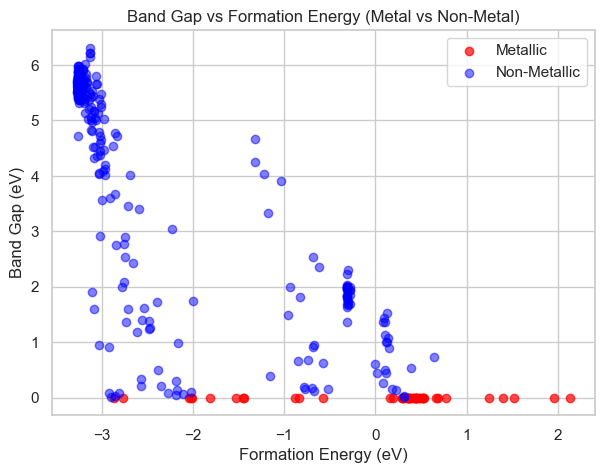

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

metal = df[df["Is Metal"] == True]
non_metal = df[df["Is Metal"] == False]

plt.scatter(metal["Formation Energy"], metal["Band Gap"],
            color="red", label="Metallic", alpha=0.7)

plt.scatter(non_metal["Formation Energy"], non_metal["Band Gap"],
            color="blue", label="Non-Metallic", alpha=0.5)

plt.xlabel("Formation Energy (eV)")
plt.ylabel("Band Gap (eV)")
plt.title("Band Gap vs Formation Energy (Metal vs Non-Metal)")
plt.legend()
plt.grid(True)

plt.show()

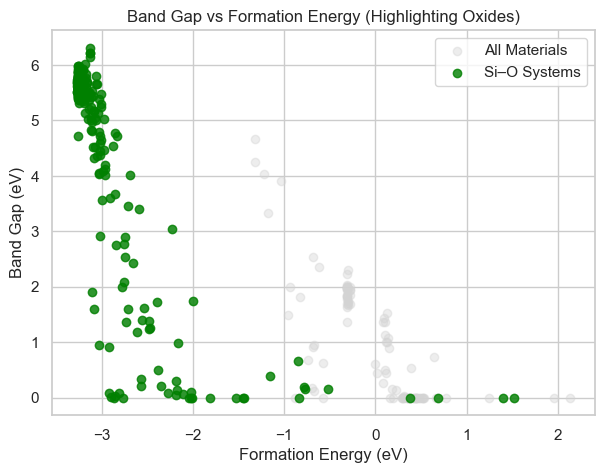

In [39]:
df_sio = df[
    (df["Si_frac"] > 0) &
    (df["O_frac"] > 0) &
    (df["C_frac"] == 0) &
    (df["N_frac"] == 0)
]

plt.figure(figsize=(7,5))

plt.scatter(df["Formation Energy"], df["Band Gap"],
            color="lightgray", alpha=0.4, label="All Materials")

plt.scatter(df_sio["Formation Energy"], df_sio["Band Gap"],
            color="green", alpha=0.8, label="Si–O Systems")

plt.xlabel("Formation Energy (eV)")
plt.ylabel("Band Gap (eV)")
plt.title("Band Gap vs Formation Energy (Highlighting Oxides)")
plt.legend()
plt.grid(True)

plt.show()

In [14]:
df[abs(df["O_frac"] - 0.666667) < 1e-4][
    ["Band Gap", "Crystal System", "Space Group Number"]
]

,Band Gap,Crystal System,Space Group Number
62,1.7396,Cubic,225
63,4.5285,Cubic,224
64,4.7160,Orthorhombic,72
65,5.5318,Hexagonal,181
66,5.2394,Orthorhombic,60
...,...,...,...
378,5.5344,Hexagonal,191
379,4.0091,Cubic,205
380,5.5882,Monoclinic,4
381,5.7565,Monoclinic,14


CORRELATION MATRIX

In [21]:
df[[
    "Band Gap",
    "Si_frac",
    "O_frac",
    "C_frac",
    "N_frac",
    "Density",
    "Volume",
    "Energy Above Hull"
]].corr()

,Band Gap,Si_frac,O_frac,C_frac,N_frac,Density,Volume,Energy Above Hull
Band Gap,1.000000,-0.619587,0.678670,-0.303737,-0.183290,-0.436771,0.279569,-0.556716
Si_frac,-0.619587,1.000000,-0.787140,0.095069,0.015408,0.313915,-0.168909,0.080618
O_frac,0.678670,-0.787140,1.000000,-0.537636,-0.388388,-0.559757,0.255279,-0.091300
C_frac,-0.303737,0.095069,-0.537636,1.000000,-0.059013,0.437908,-0.202114,-0.004924
N_frac,-0.183290,0.015408,-0.388388,-0.059013,1.000000,0.280563,-0.078495,0.085049
Density,-0.436771,0.313915,-0.559757,0.437908,0.280563,1.000000,-0.528351,0.079478
Volume,0.279569,-0.168909,0.255279,-0.202114,-0.078495,-0.528351,1.000000,-0.150487
Energy Above Hull,-0.556716,0.080618,-0.091300,-0.004924,0.085049,0.079478,-0.150487,1.000000


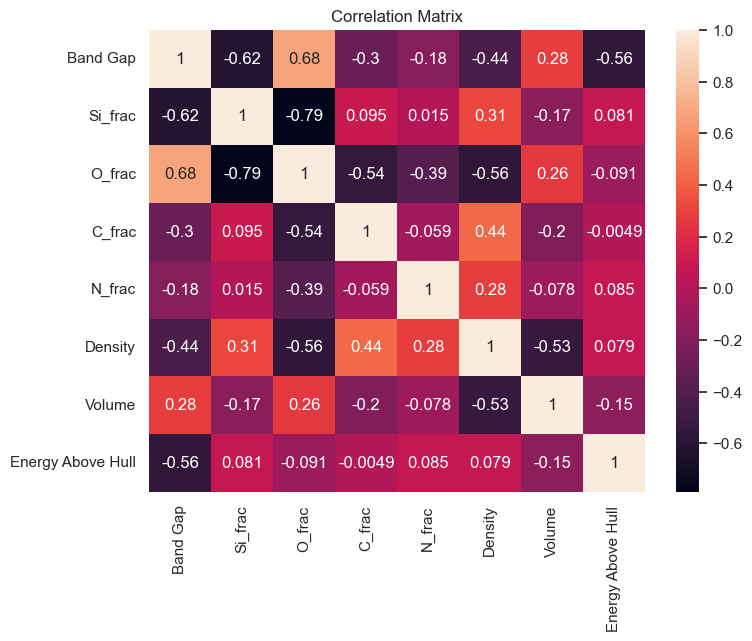

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    df[[
        "Band Gap",
        "Si_frac",
        "O_frac",
        "C_frac",
        "N_frac",
        "Density",
        "Volume",
        "Energy Above Hull"
    ]].corr(),
    annot=True,
    
)

plt.title("Correlation Matrix")
plt.show()